# Car Market Analysis – Car Dekho Data

**Data Analytics Internship Project – Edunet Foundation**

This notebook analyzes the Car Dekho used-vehicle dataset using **Python, Pandas, NumPy, Matplotlib and Seaborn**.

The analysis answers all 25 questions supplied in the project instructions and creates visualizations for the important findings.


## 1. Import Required Libraries

In [87]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

pd.set_option("display.max_columns", None)
pd.set_option("display.max_rows", 100)

sns.set_theme(style="whitegrid")


## 2. Load the Dataset

In [88]:
# Upload Car_Dekho_Data.csv to Colab before running this cell.
file_path = "Car_Dekho_DA.csv"

df = pd.read_csv(file_path)

print("Dataset loaded successfully.")
print("Shape:", df.shape)
df.head()


Dataset loaded successfully.
Shape: (301, 9)


,Car_Name,Year,Selling_Price,Present_Price,Kms_Driven,Fuel_Type,Seller_Type,Transmission,Owner
0,ritz,2014,3.35,5.59,27000,Petrol,Dealer,Manual,0
1,sx4,2013,4.75,9.54,43000,Diesel,Dealer,Manual,0
2,ciaz,2017,7.25,9.85,6900,Petrol,Dealer,Manual,0
3,wagon r,2011,2.85,4.15,5200,Petrol,Dealer,Manual,0
4,swift,2014,4.60,6.87,42450,Diesel,Dealer,Manual,0


## 3. Basic Data Understanding

In [89]:
print("Number of records:", len(df))
print("Number of columns:", len(df.columns))
print("\nColumn names:")
print(df.columns.tolist())

print("\nData types:")
print(df.dtypes)

print("\nDataset information:")
df.info()


Number of records: 301
Number of columns: 9

Column names:
['Car_Name', 'Year', 'Selling_Price', 'Present_Price', 'Kms_Driven', 'Fuel_Type', 'Seller_Type', 'Transmission', 'Owner']

Data types:
Car_Name          object
Year               int64
Selling_Price    float64
Present_Price    float64
Kms_Driven         int64
Fuel_Type         object
Seller_Type       object
Transmission      object
Owner              int64
dtype: object

Dataset information:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 301 entries, 0 to 300
Data columns (total 9 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Car_Name       301 non-null    object 
 1   Year           301 non-null    int64  
 2   Selling_Price  301 non-null    float64
 3   Present_Price  301 non-null    float64
 4   Kms_Driven     301 non-null    int64  
 5   Fuel_Type      301 non-null    object 
 6   Seller_Type    301 non-null    object 
 7   Transmission   301 non-null    object 
 

## 4. Check Missing Values and Duplicates

In [90]:
print("Missing values in each column:")
print(df.isnull().sum())

print("\nTotal missing values:", df.isnull().sum().sum())

print("\nDuplicate rows:", df.duplicated().sum())


Missing values in each column:
Car_Name         0
Year             0
Selling_Price    0
Present_Price    0
Kms_Driven       0
Fuel_Type        0
Seller_Type      0
Transmission     0
Owner            0
dtype: int64

Total missing values: 0

Duplicate rows: 2


## 5. Data Cleaning and Feature Preparation

The original dataset is preserved. A copy is used for analysis.

We standardize text fields, create vehicle age, depreciation, depreciation percentage, price-retention percentage, vehicle type and brand.


In [91]:
data = df.copy()

# Remove accidental leading/trailing spaces from text columns
text_columns = ["Car_Name", "Fuel_Type", "Seller_Type", "Transmission"]
for col in text_columns:
    data[col] = data[col].astype(str).str.strip()

# Numeric conversion
numeric_columns = ["Year", "Selling_Price", "Present_Price", "Kms_Driven", "Owner"]
for col in numeric_columns:
    data[col] = pd.to_numeric(data[col], errors="coerce")

# Vehicle age relative to the latest manufacturing year in the dataset
reference_year = data["Year"].max()
data["Vehicle_Age"] = reference_year - data["Year"]

# Absolute price difference between present/reference price and selling price
data["Depreciation"] = data["Present_Price"] - data["Selling_Price"]

# Percentage depreciation relative to present price
data["Depreciation_Percent"] = (
    data["Depreciation"] / data["Present_Price"]
) * 100

# Selling price retained from present price
data["Price_Retention_Percent"] = (
    data["Selling_Price"] / data["Present_Price"]
) * 100

# A transparent two-wheeler classifier for this dataset
two_wheeler_keywords = [
    "royal enfield", "um ", "ktm", "bajaj", "hyosung", "mahindra mojo",
    "honda cb", "honda cbr", "honda activa", "honda dream", "honda karizma",
    "hero ", "tvs ", "yamaha ", "suzuki access"
]

def classify_vehicle(name):
    name = name.lower().strip()
    return "Two-Wheeler" if any(k in name for k in two_wheeler_keywords) else "Car"

data["Vehicle_Type"] = data["Car_Name"].apply(classify_vehicle)

# Brand mapping based on model names present in this dataset
def get_brand(name):
    n = name.lower().strip()

    if n.startswith(("royal enfield",)):
        return "Royal Enfield"
    if n.startswith(("bajaj",)):
        return "Bajaj"
    if n.startswith(("ktm",)):
        return "KTM"
    if n.startswith(("yamaha",)):
        return "Yamaha"
    if n.startswith(("tvs",)):
        return "TVS"
    if n.startswith(("hero",)):
        return "Hero"
    if n.startswith(("honda",)):
        return "Honda"
    if n.startswith(("suzuki",)):
        return "Suzuki"
    if n.startswith(("um ",)):
        return "UM"
    if n.startswith(("hyosung",)):
        return "Hyosung"
    if n.startswith(("mahindra",)):
        return "Mahindra"

    # Car brands
    if n in ["ritz", "sx4", "ciaz", "wagon r", "swift", "vitara brezza",
             "s cross", "alto 800", "alto k10", "ertiga", "dzire", "ignis",
             "baleno", "omni", "800"]:
        return "Maruti Suzuki"
    if n in ["fortuner", "innova", "corolla altis", "corolla", "etios cross",
             "etios g", "etios liva", "etios gd", "camry", "land cruiser"]:
        return "Toyota"
    if n in ["i20", "grand i10", "i10", "eon", "xcent", "elantra", "creta", "verna"]:
        return "Hyundai"
    if n in ["city", "brio", "amaze", "jazz"]:
        return "Honda"

    return "Other"

data["Brand"] = data["Car_Name"].apply(get_brand)

print("Prepared dataset shape:", data.shape)
data.head()


Prepared dataset shape: (301, 15)


,Car_Name,Year,Selling_Price,Present_Price,Kms_Driven,Fuel_Type,Seller_Type,Transmission,Owner,Vehicle_Age,Depreciation,Depreciation_Percent,Price_Retention_Percent,Vehicle_Type,Brand
0,ritz,2014,3.35,5.59,27000,Petrol,Dealer,Manual,0,4,2.24,40.071556,59.928444,Car,Maruti Suzuki
1,sx4,2013,4.75,9.54,43000,Diesel,Dealer,Manual,0,5,4.79,50.209644,49.790356,Car,Maruti Suzuki
2,ciaz,2017,7.25,9.85,6900,Petrol,Dealer,Manual,0,1,2.60,26.395939,73.604061,Car,Maruti Suzuki
3,wagon r,2011,2.85,4.15,5200,Petrol,Dealer,Manual,0,7,1.30,31.325301,68.674699,Car,Maruti Suzuki
4,swift,2014,4.60,6.87,42450,Diesel,Dealer,Manual,0,4,2.27,33.042213,66.957787,Car,Maruti Suzuki


# Question 1
## From which manufacturing year to which manufacturing year are vehicles present in this data?

In [92]:
min_year = data["Year"].min()
max_year = data["Year"].max()

print(f"Vehicles are present from manufacturing year {min_year} to {max_year}.")
print(f"Year range: {max_year - min_year} years")


Vehicles are present from manufacturing year 2003 to 2018.
Year range: 15 years


# Question 2
## What is the lowest price to which a vehicle is sold?

In [93]:
min_price = data["Selling_Price"].min()
min_row = data.loc[data["Selling_Price"].idxmin()]

print(f"Lowest selling price: {min_price:.2f} lakh")
print("Vehicle:")
print(min_row[["Car_Name", "Year", "Selling_Price", "Present_Price", "Kms_Driven"]])


Lowest selling price: 0.10 lakh
Vehicle:
Car_Name         Bajaj Pulsar 150
Year                         2006
Selling_Price                 0.1
Present_Price                0.75
Kms_Driven                  92233
Name: 200, dtype: object


# Question 3
## What is the highest price to which a vehicle is sold?

In [94]:
max_price = data["Selling_Price"].max()
max_row = data.loc[data["Selling_Price"].idxmax()]

print(f"Highest selling price: {max_price:.2f} lakh")
print("Vehicle:")
print(max_row[["Car_Name", "Year", "Selling_Price", "Present_Price", "Kms_Driven"]])


Highest selling price: 35.00 lakh
Vehicle:
Car_Name         land cruiser
Year                     2010
Selling_Price            35.0
Present_Price            92.6
Kms_Driven              78000
Name: 86, dtype: object


# Question 4
## How many records are there in this data?

In [95]:
print("Total records:", len(data))


Total records: 301


# Question 5
## Are there any missing records in this data?

In [96]:
missing = data.isnull().sum()
print(missing)

if missing.sum() == 0:
    print("\nConclusion: There are no missing values in the dataset.")
else:
    print("\nConclusion: Missing values are present.")


Car_Name                   0
Year                       0
Selling_Price              0
Present_Price              0
Kms_Driven                 0
Fuel_Type                  0
Seller_Type                0
Transmission               0
Owner                      0
Vehicle_Age                0
Depreciation               0
Depreciation_Percent       0
Price_Retention_Percent    0
Vehicle_Type               0
Brand                      0
dtype: int64

Conclusion: There are no missing values in the dataset.


# Question 6
## How many different vehicles are present in this data?

In [97]:
unique_vehicles = data["Car_Name"].nunique()
print("Number of different vehicle models:", unique_vehicles)


Number of different vehicle models: 98


# Question 7
## Which is the most sold vehicle in this data?

In [98]:
vehicle_counts = data["Car_Name"].value_counts()
most_sold_count = vehicle_counts.max()
most_sold_vehicles = vehicle_counts[vehicle_counts == most_sold_count]

print("Most frequently occurring vehicle(s):")
print(most_sold_vehicles)


Most frequently occurring vehicle(s):
Car_Name
city    26
Name: count, dtype: int64


### Visualization – Most Frequently Occurring Vehicles

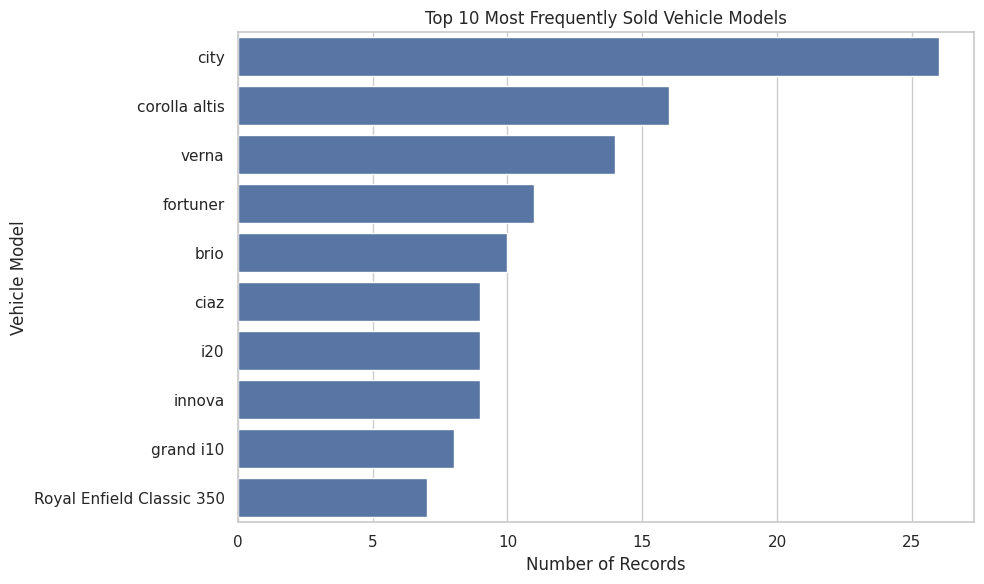

In [99]:
top_vehicles = vehicle_counts.head(10)

plt.figure(figsize=(10, 6))
sns.barplot(x=top_vehicles.values, y=top_vehicles.index)
plt.title("Top 10 Most Frequently Sold Vehicle Models")
plt.xlabel("Number of Records")
plt.ylabel("Vehicle Model")
plt.tight_layout()
plt.show()


# Question 8
## Does the database include any CNG vehicle? If yes, how many?

In [100]:
cng_count = (data["Fuel_Type"].str.upper() == "CNG").sum()

print("Number of CNG vehicles:", cng_count)

if cng_count > 0:
    print("\nCNG vehicle records:")
    display(data[data["Fuel_Type"].str.upper() == "CNG"][
        ["Car_Name", "Year", "Selling_Price", "Present_Price", "Kms_Driven"]
    ])


Number of CNG vehicles: 2

CNG vehicle records:


,Car_Name,Year,Selling_Price,Present_Price,Kms_Driven
18,wagon r,2015,3.25,5.09,35500
35,sx4,2011,2.95,7.74,49998


# Question 9
## How many vehicles are sold from Individuals directly?

In [101]:
individual_count = (data["Seller_Type"].str.lower() == "individual").sum()
print("Vehicles sold by Individual sellers:", individual_count)


Vehicles sold by Individual sellers: 106


# Question 10
## Does the database contain auto transmission vehicles? If yes, how many?

In [102]:
automatic_count = (data["Transmission"].str.lower() == "automatic").sum()

print("Automatic transmission vehicles:", automatic_count)

print("\nTransmission distribution:")
print(data["Transmission"].value_counts())


Automatic transmission vehicles: 40

Transmission distribution:
Transmission
Manual       261
Automatic     40
Name: count, dtype: int64


### Visualization – Transmission Distribution

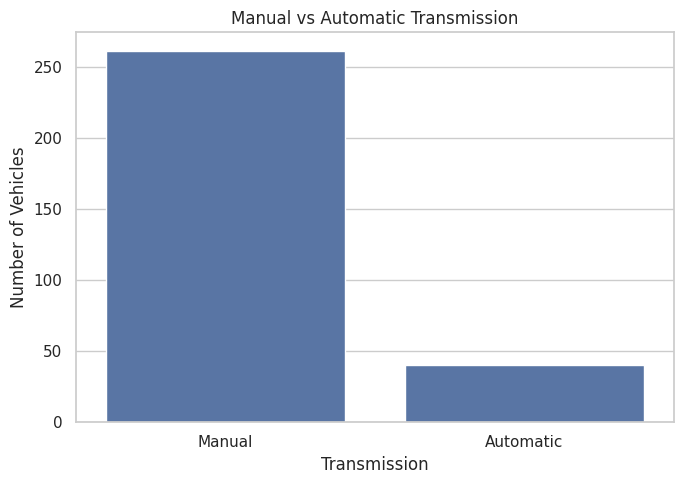

In [103]:
plt.figure(figsize=(7, 5))
sns.countplot(data=data, x="Transmission")
plt.title("Manual vs Automatic Transmission")
plt.xlabel("Transmission")
plt.ylabel("Number of Vehicles")
plt.tight_layout()
plt.show()


# Question 11
## How many single-person-owned vehicles are there in the database?

In [104]:
single_owner_count = (data["Owner"] == 1).sum()
print("Vehicles with exactly one previous owner:", single_owner_count)

print("\nOwner distribution:")
print(data["Owner"].value_counts().sort_index())


Vehicles with exactly one previous owner: 10

Owner distribution:
Owner
0    290
1     10
3      1
Name: count, dtype: int64


# Question 12
## Which is the most and least cost-depreciated vehicle in the data?

**Definition used:**  
`Depreciation = Present_Price - Selling_Price`

A larger positive value means a larger fall from the recorded present price to the selling price. Negative depreciation means the selling price is above the recorded present price and is therefore better interpreted as **price appreciation / unusually strong resale retention**, not physical depreciation.


In [105]:
most_depreciated = data.loc[data["Depreciation"].idxmax()]
least_depreciated = data.loc[data["Depreciation"].idxmin()]

print("Most cost-depreciated vehicle:")
display(most_depreciated[[
    "Car_Name", "Year", "Selling_Price", "Present_Price",
    "Depreciation", "Depreciation_Percent", "Kms_Driven"
]].to_frame().T)

print("\nLeast depreciated / highest price-retention observation:")
display(least_depreciated[[
    "Car_Name", "Year", "Selling_Price", "Present_Price",
    "Depreciation", "Depreciation_Percent", "Kms_Driven"
]].to_frame().T)


Most cost-depreciated vehicle:


,Car_Name,Year,Selling_Price,Present_Price,Depreciation,Depreciation_Percent,Kms_Driven
86,land cruiser,2010,35.0,92.6,57.6,62.203024,78000



Least depreciated / highest price-retention observation:


,Car_Name,Year,Selling_Price,Present_Price,Depreciation,Depreciation_Percent,Kms_Driven
155,Honda Activa 4G,2017,0.48,0.51,0.03,5.882353,4300


# Question 13
## Which brands of vehicles are least affected by cost depreciation?

In [106]:
brand_depreciation = (
    data.groupby("Brand")
        .agg(
            Vehicles=("Car_Name", "count"),
            Avg_Depreciation=("Depreciation", "mean"),
            Avg_Depreciation_Percent=("Depreciation_Percent", "mean"),
            Avg_Retention=("Price_Retention_Percent", "mean")
        )
        .sort_values("Avg_Depreciation_Percent")
)

print("Brands ordered from least average depreciation to highest:")
display(brand_depreciation.round(2))

print("\nTop 5 brands with the lowest average depreciation percentage:")
display(brand_depreciation.head(5).round(2))


Brands ordered from least average depreciation to highest:


,Vehicles,Avg_Depreciation,Avg_Depreciation_Percent,Avg_Retention
Brand,,,,
UM,1,0.12,6.59,93.41
Mahindra,1,0.25,17.86,82.14
Royal Enfield,17,0.42,26.14,73.86
Hyundai,50,2.18,29.15,70.85
Yamaha,8,0.26,30.65,69.35
KTM,4,0.75,33.75,66.25
TVS,8,0.24,33.89,66.11
Other,3,0.18,35.18,64.82
Honda,67,2.48,35.34,64.66



Top 5 brands with the lowest average depreciation percentage:


,Vehicles,Avg_Depreciation,Avg_Depreciation_Percent,Avg_Retention
Brand,,,,
UM,1,0.12,6.59,93.41
Mahindra,1,0.25,17.86,82.14
Royal Enfield,17,0.42,26.14,73.86
Hyundai,50,2.18,29.15,70.85
Yamaha,8,0.26,30.65,69.35


### Visualization – Average Depreciation by Brand

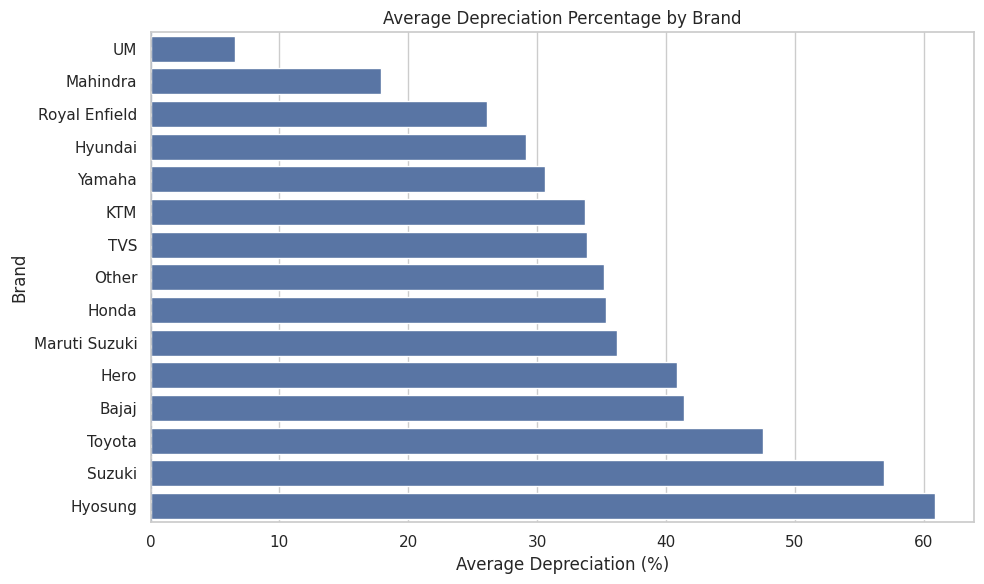

In [107]:
plot_data = brand_depreciation.sort_values("Avg_Depreciation_Percent")

plt.figure(figsize=(10, 6))
sns.barplot(
    data=plot_data,
    x="Avg_Depreciation_Percent",
    y=plot_data.index
)
plt.axvline(0, linestyle="--")
plt.title("Average Depreciation Percentage by Brand")
plt.xlabel("Average Depreciation (%)")
plt.ylabel("Brand")
plt.tight_layout()
plt.show()


# Question 14
## Are there any factors which you feel affect the cost depreciation?

We examine:
- Vehicle age
- Kilometers driven
- Selling price / present price relationship
- Fuel type
- Seller type
- Transmission
- Ownership history

The analysis uses correlation and group averages rather than claiming that correlation proves causation.


In [108]:
print("Correlation with depreciation percentage:")
print(
    data[[
        "Vehicle_Age", "Kms_Driven", "Selling_Price",
        "Present_Price", "Owner", "Depreciation_Percent"
    ]].corr()["Depreciation_Percent"].sort_values()
)

print("\nAverage depreciation percentage by fuel type:")
display(
    data.groupby("Fuel_Type")["Depreciation_Percent"]
        .mean()
        .sort_values()
        .round(2)
        .to_frame("Average_Depreciation_Percent")
)

print("\nAverage depreciation percentage by seller type:")
display(
    data.groupby("Seller_Type")["Depreciation_Percent"]
        .mean()
        .sort_values()
        .round(2)
        .to_frame("Average_Depreciation_Percent")
)

print("\nAverage depreciation percentage by transmission:")
display(
    data.groupby("Transmission")["Depreciation_Percent"]
        .mean()
        .sort_values()
        .round(2)
        .to_frame("Average_Depreciation_Percent")
)

print("\nAverage depreciation percentage by owner count:")
display(
    data.groupby("Owner")["Depreciation_Percent"]
        .mean()
        .sort_values()
        .round(2)
        .to_frame("Average_Depreciation_Percent")
)


Correlation with depreciation percentage:
Selling_Price          -0.232544
Present_Price           0.102439
Owner                   0.222572
Kms_Driven              0.505896
Vehicle_Age             0.848699
Depreciation_Percent    1.000000
Name: Depreciation_Percent, dtype: float64

Average depreciation percentage by fuel type:


,Average_Depreciation_Percent
Fuel_Type,
Diesel,32.04
Petrol,37.59
CNG,49.02



Average depreciation percentage by seller type:


,Average_Depreciation_Percent
Seller_Type,
Dealer,36.00
Individual,37.58



Average depreciation percentage by transmission:


,Average_Depreciation_Percent
Transmission,
Automatic,36.07
Manual,36.63



Average depreciation percentage by owner count:


,Average_Depreciation_Percent
Owner,
0,35.76
1,54.18
3,89.46


# Question 15
## In general, selling price is affected by age and distance driven. Is it observable from the data?

In [109]:
age_corr = data["Vehicle_Age"].corr(data["Selling_Price"])
kms_corr = data["Kms_Driven"].corr(data["Selling_Price"])

print(f"Correlation between vehicle age and selling price: {age_corr:.3f}")
print(f"Correlation between kilometers driven and selling price: {kms_corr:.3f}")

if age_corr < 0:
    print("Observation: Older vehicles generally tend to have lower selling prices.")
if kms_corr < 0:
    print("Observation: Higher kilometers driven generally tend to be associated with lower selling prices.")


Correlation between vehicle age and selling price: -0.236
Correlation between kilometers driven and selling price: 0.029
Observation: Older vehicles generally tend to have lower selling prices.


### Visualization – Age vs Selling Price

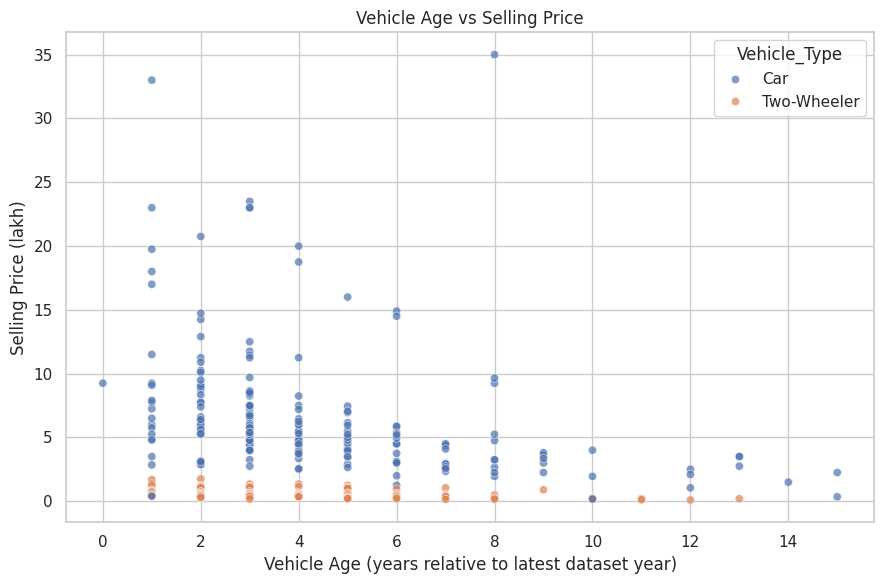

In [110]:
plt.figure(figsize=(9, 6))
sns.scatterplot(data=data, x="Vehicle_Age", y="Selling_Price", hue="Vehicle_Type", alpha=0.7)
plt.title("Vehicle Age vs Selling Price")
plt.xlabel("Vehicle Age (years relative to latest dataset year)")
plt.ylabel("Selling Price (lakh)")
plt.tight_layout()
plt.show()


### Visualization – Kilometers Driven vs Selling Price

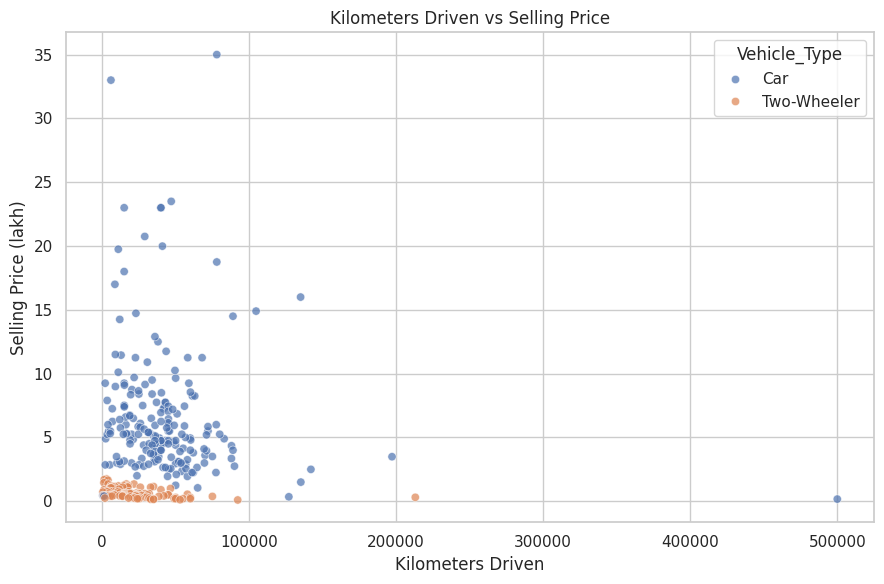

In [111]:
plt.figure(figsize=(9, 6))
sns.scatterplot(data=data, x="Kms_Driven", y="Selling_Price", hue="Vehicle_Type", alpha=0.7)
plt.title("Kilometers Driven vs Selling Price")
plt.xlabel("Kilometers Driven")
plt.ylabel("Selling Price (lakh)")
plt.tight_layout()
plt.show()


# Question 16
## Can we get data about the newest vehicles, i.e. manufactured after 2014?

In [112]:
newest_vehicles = data[data["Year"] > 2014].copy()

print("Vehicles manufactured after 2014:", len(newest_vehicles))
display(newest_vehicles.head(10))


Vehicles manufactured after 2014: 147


,Car_Name,Year,Selling_Price,Present_Price,Kms_Driven,Fuel_Type,Seller_Type,Transmission,Owner,Vehicle_Age,Depreciation,Depreciation_Percent,Price_Retention_Percent,Vehicle_Type,Brand
2,ciaz,2017,7.25,9.85,6900,Petrol,Dealer,Manual,0,1,2.60,26.395939,73.604061,Car,Maruti Suzuki
5,vitara brezza,2018,9.25,9.83,2071,Diesel,Dealer,Manual,0,0,0.58,5.900305,94.099695,Car,Maruti Suzuki
6,ciaz,2015,6.75,8.12,18796,Petrol,Dealer,Manual,0,3,1.37,16.871921,83.128079,Car,Maruti Suzuki
7,s cross,2015,6.50,8.61,33429,Diesel,Dealer,Manual,0,3,2.11,24.506388,75.493612,Car,Maruti Suzuki
8,ciaz,2016,8.75,8.89,20273,Diesel,Dealer,Manual,0,2,0.14,1.574803,98.425197,Car,Maruti Suzuki
9,ciaz,2015,7.45,8.92,42367,Diesel,Dealer,Manual,0,3,1.47,16.479821,83.520179,Car,Maruti Suzuki
10,alto 800,2017,2.85,3.60,2135,Petrol,Dealer,Manual,0,1,0.75,20.833333,79.166667,Car,Maruti Suzuki
11,ciaz,2015,6.85,10.38,51000,Diesel,Dealer,Manual,0,3,3.53,34.007707,65.992293,Car,Maruti Suzuki
12,ciaz,2015,7.50,9.94,15000,Petrol,Dealer,Automatic,0,3,2.44,24.547284,75.452716,Car,Maruti Suzuki
13,ertiga,2015,6.10,7.71,26000,Petrol,Dealer,Manual,0,3,1.61,20.881971,79.118029,Car,Maruti Suzuki


### Count of Vehicles Manufactured After 2014 by Year

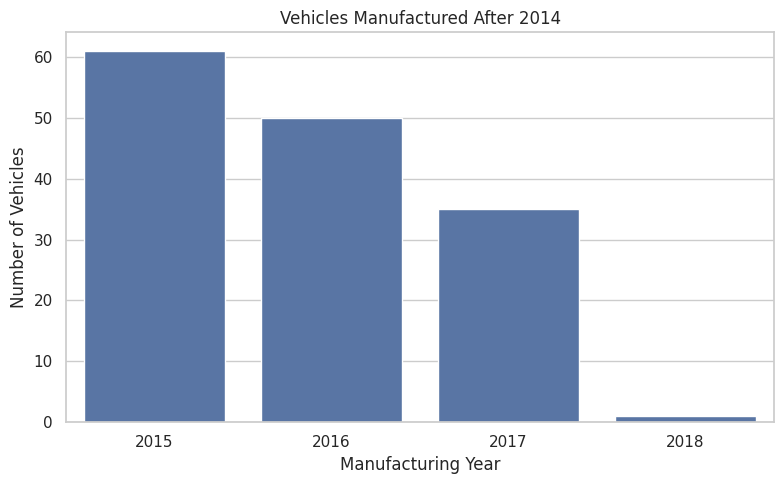

In [113]:
newest_by_year = newest_vehicles["Year"].value_counts().sort_index()

plt.figure(figsize=(8, 5))
sns.barplot(x=newest_by_year.index.astype(str), y=newest_by_year.values)
plt.title("Vehicles Manufactured After 2014")
plt.xlabel("Manufacturing Year")
plt.ylabel("Number of Vehicles")
plt.tight_layout()
plt.show()


# Question 17
## Can we find out data of only two-wheelers from this data?

In [114]:
two_wheelers = data[data["Vehicle_Type"] == "Two-Wheeler"].copy()

print("Number of two-wheelers:", len(two_wheelers))
display(two_wheelers.head(10))


Number of two-wheelers: 98


,Car_Name,Year,Selling_Price,Present_Price,Kms_Driven,Fuel_Type,Seller_Type,Transmission,Owner,Vehicle_Age,Depreciation,Depreciation_Percent,Price_Retention_Percent,Vehicle_Type,Brand
100,Royal Enfield Thunder 500,2016,1.75,1.90,3000,Petrol,Individual,Manual,0,2,0.15,7.894737,92.105263,Two-Wheeler,Royal Enfield
101,UM Renegade Mojave,2017,1.70,1.82,1400,Petrol,Individual,Manual,0,1,0.12,6.593407,93.406593,Two-Wheeler,UM
102,KTM RC200,2017,1.65,1.78,4000,Petrol,Individual,Manual,0,1,0.13,7.303371,92.696629,Two-Wheeler,KTM
103,Bajaj Dominar 400,2017,1.45,1.60,1200,Petrol,Individual,Manual,0,1,0.15,9.375000,90.625000,Two-Wheeler,Bajaj
104,Royal Enfield Classic 350,2017,1.35,1.47,4100,Petrol,Individual,Manual,0,1,0.12,8.163265,91.836735,Two-Wheeler,Royal Enfield
105,KTM RC390,2015,1.35,2.37,21700,Petrol,Individual,Manual,0,3,1.02,43.037975,56.962025,Two-Wheeler,KTM
106,Hyosung GT250R,2014,1.35,3.45,16500,Petrol,Individual,Manual,1,4,2.10,60.869565,39.130435,Two-Wheeler,Hyosung
107,Royal Enfield Thunder 350,2013,1.25,1.50,15000,Petrol,Individual,Manual,0,5,0.25,16.666667,83.333333,Two-Wheeler,Royal Enfield
108,Royal Enfield Thunder 350,2016,1.20,1.50,18000,Petrol,Individual,Manual,0,2,0.30,20.000000,80.000000,Two-Wheeler,Royal Enfield
109,Royal Enfield Classic 350,2017,1.20,1.47,11000,Petrol,Individual,Manual,0,1,0.27,18.367347,81.632653,Two-Wheeler,Royal Enfield


# Question 18
## Which is the oldest bike sold here?

In [115]:
oldest_bike_year = two_wheelers["Year"].min()
oldest_bikes = two_wheelers[two_wheelers["Year"] == oldest_bike_year]

print("Oldest bike manufacturing year:", oldest_bike_year)
display(oldest_bikes[
    ["Car_Name", "Year", "Selling_Price", "Present_Price", "Kms_Driven", "Owner"]
])


Oldest bike manufacturing year: 2005


,Car_Name,Year,Selling_Price,Present_Price,Kms_Driven,Owner
189,Hero Super Splendor,2005,0.2,0.57,55000,0


# Question 19
## Which is the newest bike sold here?

In [116]:
newest_bike_year = two_wheelers["Year"].max()
newest_bikes = two_wheelers[two_wheelers["Year"] == newest_bike_year]

print("Newest bike manufacturing year:", newest_bike_year)
display(newest_bikes[
    ["Car_Name", "Year", "Selling_Price", "Present_Price", "Kms_Driven", "Owner"]
])


Newest bike manufacturing year: 2017


,Car_Name,Year,Selling_Price,Present_Price,Kms_Driven,Owner
101,UM Renegade Mojave,2017,1.70,1.82,1400,0
102,KTM RC200,2017,1.65,1.78,4000,0
103,Bajaj Dominar 400,2017,1.45,1.60,1200,0
104,Royal Enfield Classic 350,2017,1.35,1.47,4100,0
109,Royal Enfield Classic 350,2017,1.20,1.47,11000,0
126,Bajaj Avenger 220,2017,0.90,0.95,1300,0
128,Honda CB Hornet 160R,2017,0.80,0.87,3000,0
129,Yamaha FZ S V 2.0,2017,0.78,0.84,5000,0
130,Honda CB Hornet 160R,2017,0.75,0.87,11000,0
132,Bajaj Avenger 220,2017,0.75,0.95,3500,0


# Question 20
## Which is the most sold bike here?

In [117]:
bike_counts = two_wheelers["Car_Name"].value_counts()
most_sold_bike_count = bike_counts.max()
most_sold_bikes = bike_counts[bike_counts == most_sold_bike_count]

print("Most frequently sold bike(s):")
print(most_sold_bikes)


Most frequently sold bike(s):
Car_Name
Royal Enfield Classic 350    7
Name: count, dtype: int64


### Visualization – Most Sold Two-Wheelers

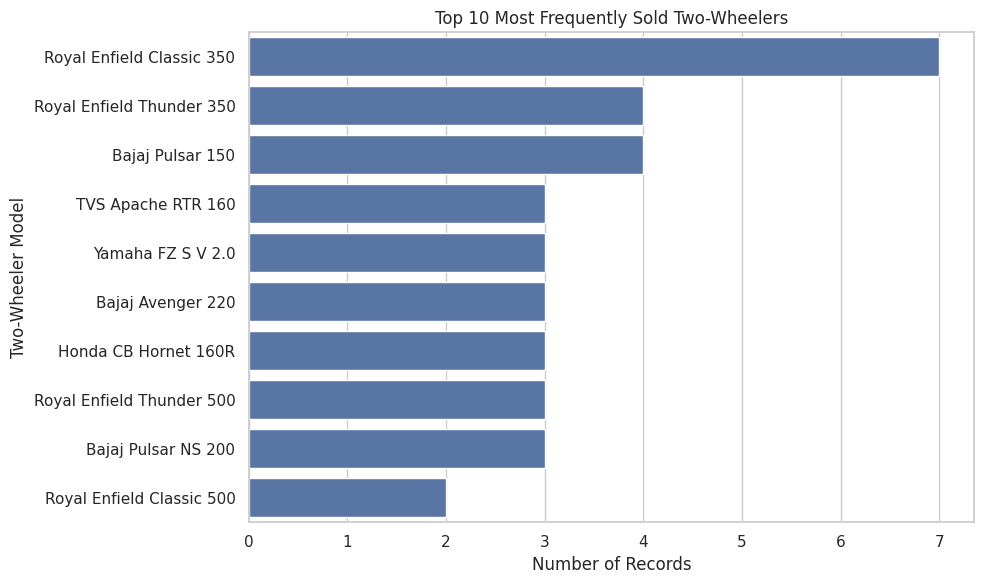

In [118]:
top_bikes = bike_counts.head(10)

plt.figure(figsize=(10, 6))
sns.barplot(x=top_bikes.values, y=top_bikes.index)
plt.title("Top 10 Most Frequently Sold Two-Wheelers")
plt.xlabel("Number of Records")
plt.ylabel("Two-Wheeler Model")
plt.tight_layout()
plt.show()


# Question 21
## Do you find any deal in two-wheelers which exceeded the general expectation? Can you find a reason for it?

We define an **exceptional resale deal** as a two-wheeler with unusually high price retention, while also considering low kilometers and recent manufacturing year.

This is an analytical definition for the project, not a claim about the original seller's reason.


In [119]:
bike_deals = two_wheelers.copy()

# Price retention is the primary deal indicator
bike_deals = bike_deals.sort_values(
    ["Price_Retention_Percent", "Year", "Kms_Driven"],
    ascending=[False, False, True]
)

print("Top two-wheeler resale-retention observations:")
display(bike_deals[[
    "Car_Name", "Year", "Selling_Price", "Present_Price",
    "Price_Retention_Percent", "Kms_Driven", "Owner"
]].head(10).round(2))


Top two-wheeler resale-retention observations:


,Car_Name,Year,Selling_Price,Present_Price,Price_Retention_Percent,Kms_Driven,Owner
126,Bajaj Avenger 220,2017,0.90,0.95,94.74,1300,0
155,Honda Activa 4G,2017,0.48,0.51,94.12,4300,0
127,Bajaj Avenger 150,2016,0.75,0.80,93.75,7000,0
101,UM Renegade Mojave,2017,1.70,1.82,93.41,1400,0
129,Yamaha FZ S V 2.0,2017,0.78,0.84,92.86,5000,0
102,KTM RC200,2017,1.65,1.78,92.70,4000,0
156,TVS Sport,2017,0.48,0.52,92.31,15000,0
100,Royal Enfield Thunder 500,2016,1.75,1.90,92.11,3000,0
128,Honda CB Hornet 160R,2017,0.80,0.87,91.95,3000,0
104,Royal Enfield Classic 350,2017,1.35,1.47,91.84,4100,0


### Interpreting the exceptional two-wheeler deal

In [120]:
best_bike_deal = bike_deals.iloc[0]

print(
    f"Best resale-retention observation: {best_bike_deal['Car_Name']} "
    f"({int(best_bike_deal['Year'])})"
)
print(f"Price retention: {best_bike_deal['Price_Retention_Percent']:.2f}%")
print(f"Kilometers driven: {int(best_bike_deal['Kms_Driven']):,}")

print(
    "\nPossible data-supported reasons: newer manufacturing year, "
    "lower kilometers driven and strong selling-price retention relative "
    "to the recorded present price."
)


Best resale-retention observation: Bajaj Avenger 220 (2017)
Price retention: 94.74%
Kilometers driven: 1,300

Possible data-supported reasons: newer manufacturing year, lower kilometers driven and strong selling-price retention relative to the recorded present price.


# Question 22
## Can we find out data of only cars from this data?

In [121]:
cars = data[data["Vehicle_Type"] == "Car"].copy()

print("Number of cars:", len(cars))
display(cars.head(10))


Number of cars: 203


,Car_Name,Year,Selling_Price,Present_Price,Kms_Driven,Fuel_Type,Seller_Type,Transmission,Owner,Vehicle_Age,Depreciation,Depreciation_Percent,Price_Retention_Percent,Vehicle_Type,Brand
0,ritz,2014,3.35,5.59,27000,Petrol,Dealer,Manual,0,4,2.24,40.071556,59.928444,Car,Maruti Suzuki
1,sx4,2013,4.75,9.54,43000,Diesel,Dealer,Manual,0,5,4.79,50.209644,49.790356,Car,Maruti Suzuki
2,ciaz,2017,7.25,9.85,6900,Petrol,Dealer,Manual,0,1,2.60,26.395939,73.604061,Car,Maruti Suzuki
3,wagon r,2011,2.85,4.15,5200,Petrol,Dealer,Manual,0,7,1.30,31.325301,68.674699,Car,Maruti Suzuki
4,swift,2014,4.60,6.87,42450,Diesel,Dealer,Manual,0,4,2.27,33.042213,66.957787,Car,Maruti Suzuki
5,vitara brezza,2018,9.25,9.83,2071,Diesel,Dealer,Manual,0,0,0.58,5.900305,94.099695,Car,Maruti Suzuki
6,ciaz,2015,6.75,8.12,18796,Petrol,Dealer,Manual,0,3,1.37,16.871921,83.128079,Car,Maruti Suzuki
7,s cross,2015,6.50,8.61,33429,Diesel,Dealer,Manual,0,3,2.11,24.506388,75.493612,Car,Maruti Suzuki
8,ciaz,2016,8.75,8.89,20273,Diesel,Dealer,Manual,0,2,0.14,1.574803,98.425197,Car,Maruti Suzuki
9,ciaz,2015,7.45,8.92,42367,Diesel,Dealer,Manual,0,3,1.47,16.479821,83.520179,Car,Maruti Suzuki


# Question 23
## Which is the oldest car sold here?

In [122]:
oldest_car_year = cars["Year"].min()
oldest_cars = cars[cars["Year"] == oldest_car_year]

print("Oldest car manufacturing year:", oldest_car_year)
display(oldest_cars[
    ["Car_Name", "Year", "Selling_Price", "Present_Price", "Kms_Driven", "Owner"]
])


Oldest car manufacturing year: 2003


,Car_Name,Year,Selling_Price,Present_Price,Kms_Driven,Owner
37,800,2003,0.35,2.28,127000,0
39,sx4,2003,2.25,7.98,62000,0


# Question 24
## Which is the newest car sold here?

In [123]:
newest_car_year = cars["Year"].max()
newest_cars = cars[cars["Year"] == newest_car_year]

print("Newest car manufacturing year:", newest_car_year)
display(newest_cars[
    ["Car_Name", "Year", "Selling_Price", "Present_Price", "Kms_Driven", "Owner"]
])


Newest car manufacturing year: 2018


,Car_Name,Year,Selling_Price,Present_Price,Kms_Driven,Owner
5,vitara brezza,2018,9.25,9.83,2071,0


# Question 25
## Do you find any deal in cars which exceeded the general expectation? Can you find a reason for it?

For this question, a strong deal is identified using high selling-price retention relative to present price, supported by lower kilometers and newer manufacturing year.


In [124]:
car_deals = cars.copy()

car_deals = car_deals.sort_values(
    ["Price_Retention_Percent", "Year", "Kms_Driven"],
    ascending=[False, False, True]
)

print("Top car resale-retention observations:")
display(car_deals[[
    "Car_Name", "Year", "Selling_Price", "Present_Price",
    "Price_Retention_Percent", "Kms_Driven", "Owner"
]].head(10).round(2))


Top car resale-retention observations:


,Car_Name,Year,Selling_Price,Present_Price,Price_Retention_Percent,Kms_Driven,Owner
80,corolla altis,2016,14.73,14.89,98.93,23000,0
8,ciaz,2016,8.75,8.89,98.43,20273,0
231,verna,2017,9.25,9.40,98.40,15001,0
208,i20,2017,7.90,8.10,97.53,3435,0
235,verna,2017,9.10,9.40,96.81,15141,0
234,grand i10,2015,5.50,5.70,96.49,4492,0
250,creta,2016,12.90,13.60,94.85,35934,0
5,vitara brezza,2018,9.25,9.83,94.10,2071,0
83,innova,2015,12.50,13.46,92.87,38000,0
27,swift,2017,6.00,6.49,92.45,16200,0


### Interpreting the exceptional car deal

In [125]:
best_car_deal = car_deals.iloc[0]

print(
    f"Best resale-retention observation: {best_car_deal['Car_Name']} "
    f"({int(best_car_deal['Year'])})"
)
print(f"Price retention: {best_car_deal['Price_Retention_Percent']:.2f}%")
print(f"Kilometers driven: {int(best_car_deal['Kms_Driven']):,}")

print(
    "\nPossible data-supported reasons: newer manufacturing year, "
    "lower kilometers driven and a selling price very close to the "
    "recorded present price."
)


Best resale-retention observation: corolla altis (2016)
Price retention: 98.93%
Kilometers driven: 23,000

Possible data-supported reasons: newer manufacturing year, lower kilometers driven and a selling price very close to the recorded present price.


# Additional Overall Analysis

These charts provide useful project-level insights beyond the 25 mandatory questions.


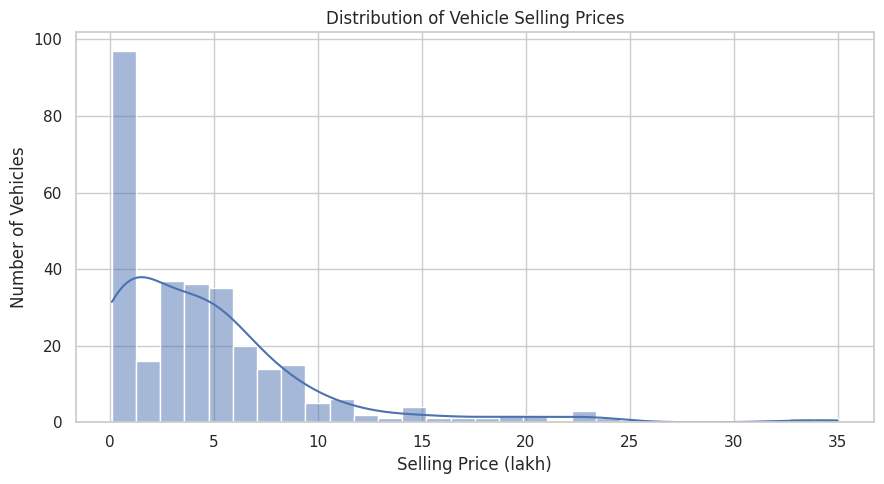

In [126]:
# Selling price distribution
plt.figure(figsize=(9, 5))
sns.histplot(data=data, x="Selling_Price", bins=30, kde=True)
plt.title("Distribution of Vehicle Selling Prices")
plt.xlabel("Selling Price (lakh)")
plt.ylabel("Number of Vehicles")
plt.tight_layout()
plt.show()


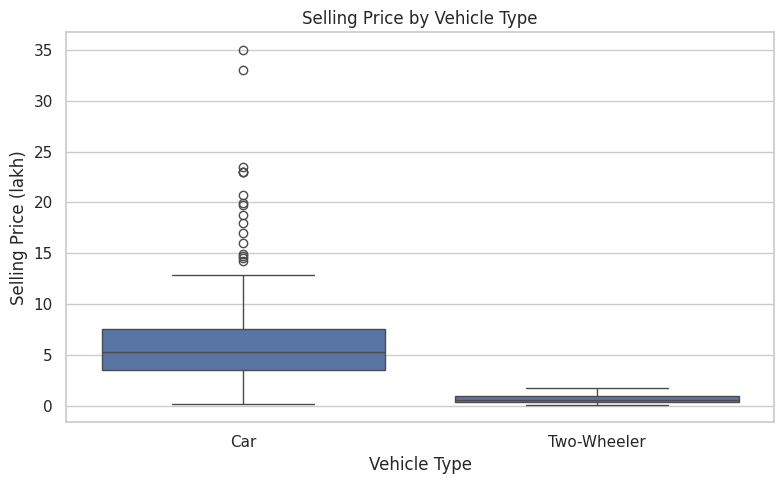

In [127]:
# Selling price by vehicle type
plt.figure(figsize=(8, 5))
sns.boxplot(data=data, x="Vehicle_Type", y="Selling_Price")
plt.title("Selling Price by Vehicle Type")
plt.xlabel("Vehicle Type")
plt.ylabel("Selling Price (lakh)")
plt.tight_layout()
plt.show()


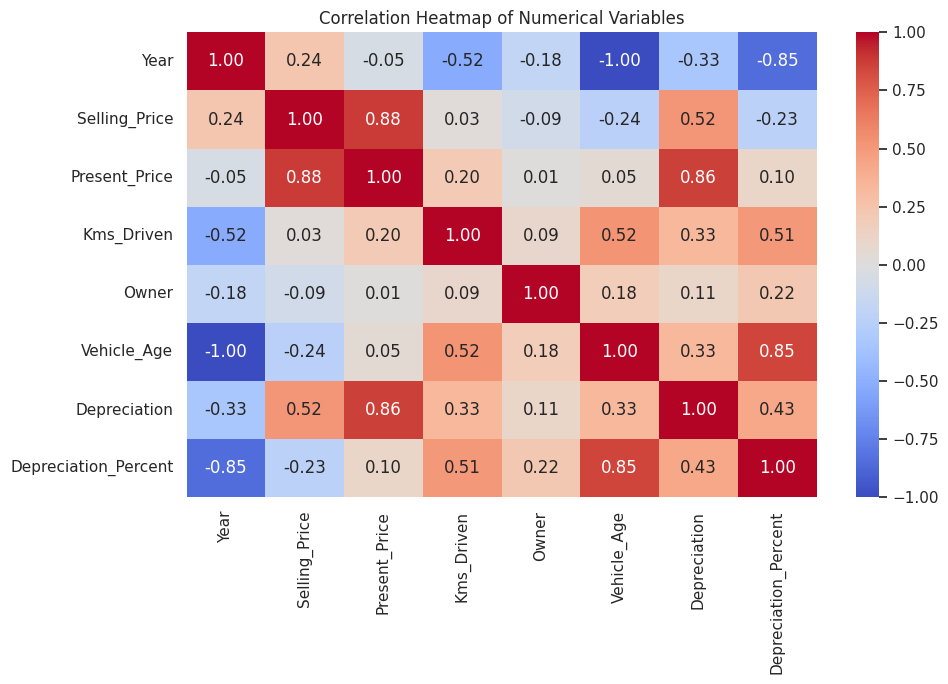

In [128]:
# Correlation heatmap
corr_cols = [
    "Year", "Selling_Price", "Present_Price",
    "Kms_Driven", "Owner", "Vehicle_Age",
    "Depreciation", "Depreciation_Percent"
]

plt.figure(figsize=(10, 7))
sns.heatmap(data[corr_cols].corr(), annot=True, fmt=".2f", cmap="coolwarm")
plt.title("Correlation Heatmap of Numerical Variables")
plt.tight_layout()
plt.show()


# Final Key Insights

Run the following cell after all analysis cells to generate a compact project summary automatically from the dataset.


In [129]:
print("========== CAR MARKET ANALYSIS – KEY INSIGHTS ==========")
print(f"1. Dataset contains {len(data)} records and {data['Car_Name'].nunique()} unique vehicle models.")
print(f"2. Manufacturing years range from {int(data['Year'].min())} to {int(data['Year'].max())}.")
print(f"3. Selling price ranges from ₹{data['Selling_Price'].min():.2f} lakh to ₹{data['Selling_Price'].max():.2f} lakh.")
print(f"4. Most frequently occurring vehicle: {vehicle_counts.index[0]} ({vehicle_counts.iloc[0]} records).")
print(f"5. CNG vehicles: {cng_count}.")
print(f"6. Individual-seller records: {individual_count}.")
print(f"7. Automatic-transmission records: {automatic_count}.")
print(f"8. Single previous-owner records: {single_owner_count}.")
print(f"9. Two-wheelers identified: {len(two_wheelers)}.")
print(f"10. Cars identified: {len(cars)}.")
print(f"11. Age vs selling-price correlation: {age_corr:.3f}.")
print(f"12. Kms-driven vs selling-price correlation: {kms_corr:.3f}.")
print("=========================================================")


========== CAR MARKET ANALYSIS – KEY INSIGHTS ==========
1. Dataset contains 301 records and 98 unique vehicle models.
2. Manufacturing years range from 2003 to 2018.
3. Selling price ranges from ₹0.10 lakh to ₹35.00 lakh.
4. Most frequently occurring vehicle: city (26 records).
5. CNG vehicles: 2.
6. Individual-seller records: 106.
7. Automatic-transmission records: 40.
8. Single previous-owner records: 10.
9. Two-wheelers identified: 98.
10. Cars identified: 203.
11. Age vs selling-price correlation: -0.236.
12. Kms-driven vs selling-price correlation: 0.029.


# Conclusion

The analysis shows how **vehicle age, usage, present price, vehicle type, seller type, transmission, ownership history and model/brand** are associated with used-vehicle selling prices.

The project demonstrates the complete data-analytics workflow:

**Data Loading → Data Cleaning → Feature Engineering → Exploratory Analysis → Visualization → Question-wise Insights → Business Interpretation**

These findings can help buyers compare vehicles, sellers understand competitive pricing, and dealers identify patterns in the used-vehicle market.
